# Оценка моделей на внешнем тесте

Ноутбук выполняет систематическую оценку обученных моделей на внешнем тестовом датасете
`test_preprocessed.csv`, подготовленном в ноутбуке 01d.

Оцениваются все варианты RuBERT-tiny и RuBERT-tiny2 (raw, norm, p), а также
отдельная модель `finetuned_rubert_tiny2` без суффикса.

Для сравнения оцениваются классические модели (Logistic Regression, LightGBM, CatBoost)
после Optuna-тюнинга.

Для каждой модели вычисляются: accuracy, precision, recall, F1, ROC-AUC, PR-AUC.
Дополнительно выполняются оптимизация порога BERT, анализ ошибок и замер latency.

## Импорты и настройка

Загружаются библиотеки для оценки метрик, визуализации и работы с моделями.
Модули проекта предоставляют функции предсказания и замера latency.

In [1]:
import os
import sys
import pickle
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from scipy.sparse import hstack
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline,
)

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.models.classical import NUMERICAL_COLUMNS, predict_message
from src.models.transformer import bert_predict_batch, benchmark_cpu_inference
from src.evaluation.metrics import optimize_threshold
from src.config import PROCESSED_DIR, MODELS_DIR, INTERIM_DIR

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## Загрузка тестовых данных

Тестовый датасет `test_preprocessed.csv` подготовлен в ноутбуке 01d и содержит
внешние данные, не пересекающиеся с обучающей выборкой.
Включает колонки `text_raw`, `text_normalized`, `text_preprocessed`, `label`
и 20 числовых признаков.

In [2]:
df_test = pd.read_csv(PROCESSED_DIR / 'test_preprocessed.csv', index_col=0)
df_test = df_test.dropna(subset=['text_preprocessed']).reset_index(drop=True)

if 'text_raw' in df_test.columns:
    raw_texts = df_test['text_raw'].astype(str).tolist()
else:
    raw_texts = [str(idx) for idx in df_test.index]

print(f'Размер тестовой выборки: {len(df_test)}')
print(f'Колонки: {list(df_test.columns)}')
df_test.head()

Размер тестовой выборки: 41369
Колонки: ['label', 'emojis', 'newlines', 'whitespaces', 'links', 'tags', 'length', 'capital_ratio', 'punctuation_count', 'digit_count', 'avg_word_length', 'word_count', 'unique_word_ratio', 'repeat_char_ratio', 'phone_count', 'has_crypto', 'exclamation_count', 'url_ratio', 'html_tag_count', 'has_markdown', 'emoji_diversity', 'text_raw', 'text_normalized', 'text_preprocessed']


,label,emojis,newlines,whitespaces,links,tags,length,capital_ratio,punctuation_count,digit_count,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
0,0,0,3,2,1,0,225,0.016304,20,6,...,0,0,0,0.537778,0,0,0,"Здравствуйте, подскажите, пожалуйста, программ...","Здравствуйте, подскажите, пожалуйста, программ...",здравствуйте подскажите пожалуйста программу м...
1,0,0,0,0,0,0,63,0.019231,3,0,...,0,0,0,0.000000,0,0,0,"Получается, все тоже самое, но теперь диплом т...","Получается, все тоже самое, но теперь диплом т...",получается все тоже самое но теперь диплом тол...
2,0,0,0,0,0,0,81,0.029412,3,0,...,0,0,0,0.000000,0,0,0,"Извините, а где можно узнать Актуальные маг пр...","Извините, а где можно узнать Актуальные маг пр...",извините а где можно узнать актуальные маг про...
3,0,0,0,0,0,0,110,0.021053,3,0,...,0,0,0,0.000000,0,0,0,"Добрый вечер, подскажите пожалуйста, есть ли з...","Добрый вечер, подскажите пожалуйста, есть ли з...",добрый вечер подскажите пожалуйста есть ли зао...
4,0,0,0,0,0,0,41,0.055556,1,0,...,0,0,1,0.000000,0,0,0,Здравствуйте! Только очная форма обучения,Здравствуйте! Только очная форма обучения,здравствуйте только очная форма обучения


In [3]:
class_counts = df_test['label'].value_counts()
print(f'Ham (0): {class_counts.get(0, 0)}')
print(f'Spam (1): {class_counts.get(1, 0)}')
print(f'Дисбаланс: {class_counts.get(0, 0) / max(class_counts.get(1, 1), 1):.1f}x')

Ham (0): 22625
Spam (1): 18744
Дисбаланс: 1.2x


## Загрузка моделей

Загружаются:
- **BERT tiny2**: `finetuned_rubert_tiny2`, `finetuned_rubert_tiny2_raw`, `finetuned_rubert_tiny2_norm`, `finetuned_rubert_tiny2_p`
- **BERT tiny**: `finetuned_rubert_tiny_raw`, `finetuned_rubert_tiny_norm`, `finetuned_rubert_tiny_p`
- **Классические**: `lr_model.pkl`, `lgbm_model.pkl`, `catboost_model.pkl` из `MODELS_DIR`
- **Препроцессоры**: `vectorizer.pkl`, `char_vectorizer.pkl`, `scaler.pkl`

Каждая BERT-модель обучалась на определённом варианте текста:
- `raw` — на `text_raw`
- `norm` — на `text_normalized`
- `p` — на `text_preprocessed`
- без суффикса — на `text_normalized` (модель по умолчанию)

In [4]:
BERT_VARIANTS = [
    {'label': 'rubert_tiny2_raw', 'dir': 'finetuned_rubert_tiny2_raw', 'text_col': 'text_raw', 'max_length': 256, 'threshold': 0.856187},
    {'label': 'rubert_tiny2_norm', 'dir': 'finetuned_rubert_tiny2_norm', 'text_col': 'text_normalized', 'max_length': 256, 'threshold': 0.815507},
    {'label': 'rubert_tiny2_p', 'dir': 'finetuned_rubert_tiny2_p', 'text_col': 'text_preprocessed', 'max_length': 256, 'threshold': 0.951362},
    {'label': 'rubert_tiny_raw', 'dir': 'finetuned_rubert_tiny_raw', 'text_col': 'text_raw', 'max_length': 256, 'threshold': 0.814425},
    {'label': 'rubert_tiny_norm', 'dir': 'finetuned_rubert_tiny_norm', 'text_col': 'text_normalized', 'max_length': 256, 'threshold': 0.802793},
    {'label': 'rubert_tiny_p', 'dir': 'finetuned_rubert_tiny_p', 'text_col': 'text_preprocessed', 'max_length': 256, 'threshold': 0.939308},
]

bert_classifiers = {}
for variant in BERT_VARIANTS:
    model_path = str(MODELS_DIR / variant['dir'])
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    bert_classifiers[variant['label']] = pipeline(
        'text-classification',
        model=model,
        tokenizer=tokenizer,
        device='cpu',
        truncation=True,
        max_length=variant['max_length'],
    )
    print(f'BERT модель загружена: {model_path} (max_length={variant["max_length"]})')

bert_classifier = bert_classifiers['rubert_tiny2_norm']

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BERT модель загружена: /home/sophrosyne/STANKIN_AntiSpam_Bot/models/finetuned_rubert_tiny2_raw (max_length=256)


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BERT модель загружена: /home/sophrosyne/STANKIN_AntiSpam_Bot/models/finetuned_rubert_tiny2_norm (max_length=256)


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

...

BERT модель загружена: /home/sophrosyne/STANKIN_AntiSpam_Bot/models/finetuned_rubert_tiny_raw (max_length=256)


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BERT модель загружена: /home/sophrosyne/STANKIN_AntiSpam_Bot/models/finetuned_rubert_tiny_norm (max_length=256)


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BERT модель загружена: /home/sophrosyne/STANKIN_AntiSpam_Bot/models/finetuned_rubert_tiny_p (max_length=256)


In [5]:
with open(MODELS_DIR / 'vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

with open(MODELS_DIR / 'char_vectorizer.pkl', 'rb') as f:
    char_vectorizer = pickle.load(f)

with open(MODELS_DIR / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

classic_models = {}
for name, filename in [('lr', 'lr_model.pkl'), ('lgbm', 'lgbm_model.pkl'), ('catboost', 'catboost_model.pkl')]:
    with open(MODELS_DIR / filename, 'rb') as f:
        classic_models[name] = pickle.load(f)

print(f'Загружено классических моделей: {len(classic_models)}')
print(f'Модели: {list(classic_models.keys())}')

Загружено классических моделей: 3
Модели: ['lr', 'lgbm', 'catboost']


## Подготовка признаков для классических моделей

Признаки готовятся из `test_preprocessed.csv` с использованием сохранённых
векторизаторов и масштабатора. Это обеспечивает совместимость формата
признаков с тем, на котором модели обучались.

In [6]:
test_texts = df_test['text_preprocessed'].astype(str).tolist()
test_labels = df_test['label'].values

word_features = vectorizer.transform(test_texts)
char_features = char_vectorizer.transform(test_texts)
num_features = df_test[NUMERICAL_COLUMNS].values
num_features_scaled = scaler.transform(num_features)

X_test = hstack([word_features, char_features, num_features_scaled]).tocsr()
print(f'X_test: {X_test.shape}')

X_test: (41369, 7020)


## Предсказание BERT

Все варианты RuBERT-tiny и RuBERT-tiny2 оцениваются на соответствующем варианте текста
(`text_raw`, `text_normalized` или `text_preprocessed`).
Порог классификации задаётся индивидуально для каждой модели в `BERT_VARIANTS`
(поле `threshold`). После оптимизации порогов значения можно обновить и перезапустить.

In [7]:
bert_preds_all = {}
bert_proba_all = {}

for variant in BERT_VARIANTS:
    label = variant['label']
    texts = df_test[variant['text_col']].astype(str).tolist()
    results = bert_predict_batch(
        texts,
        bert_classifiers[label],
        threshold=variant['threshold'],
        batch_size=16,
    )
    bert_preds_all[label] = np.array([r[0] for r in results])
    bert_proba_all[label] = np.array([r[1][1] for r in results])
    print(f'{label}: предсказаний={len(bert_preds_all[label])}, spam={bert_preds_all[label].sum()}, ham={(bert_preds_all[label] == 0).sum()}')

bert_preds = bert_preds_all['rubert_tiny2_norm']
bert_proba = bert_proba_all['rubert_tiny2_norm']

rubert_tiny2_raw: предсказаний=41369, spam=16900, ham=24469
rubert_tiny2_norm: предсказаний=41369, spam=16967, ham=24402
rubert_tiny2_p: предсказаний=41369, spam=16987, ham=24382
rubert_tiny_raw: предсказаний=41369, spam=17054, ham=24315
rubert_tiny_norm: предсказаний=41369, spam=16936, ham=24433
rubert_tiny_p: предсказаний=41369, spam=16887, ham=24482


## Предсказание классических моделей

Каждая классическая модель предсказывает на подготовленной матрице признаков `X_test`.
Сохраняются предсказания и вероятности класса spam для расчёта метрик.

In [8]:
classic_preds = {}
classic_proba = {}

for name, model in classic_models.items():
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    classic_preds[name] = preds
    classic_proba[name] = proba
    print(f'{name}: spam={preds.sum()}, ham={(preds == 0).sum()}')

lr: spam=17501, ham=23868
lgbm: spam=17218, ham=24151
catboost: spam=17019, ham=24350


## Сводная таблица метрик

Для каждой модели вычисляются: accuracy, precision (spam), recall (spam),
F1 (spam), F1-macro, ROC-AUC, PR-AUC.
Результаты сортируются по F1-macro.

In [9]:
def compute_metrics(y_true, y_pred, y_proba):
    """Вычисляет метрики классификации для одной модели."""
    return {
        'accuracy': float((y_pred == y_true).mean()),
        'precision_spam': float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        'recall_spam': float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        'f1_spam': float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, y_proba)),
        'pr_auc': float(average_precision_score(y_true, y_proba)),
    }

In [10]:
results = []

for variant in BERT_VARIANTS:
    label = variant['label']
    results.append({
        'model': label,
        **compute_metrics(test_labels, bert_preds_all[label], bert_proba_all[label]),
    })

for name in classic_models:
    results.append({
        'model': f'classic_{name}',
        **compute_metrics(test_labels, classic_preds[name], classic_proba[name]),
    })

results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,roc_auc,pr_auc
0,classic_lr,0.961154,0.989601,0.923976,0.955663,0.960549,0.986729,0.988041
1,rubert_tiny_raw,0.958181,0.998827,0.908771,0.951673,0.957409,0.998135,0.997925
2,rubert_tiny2_p,0.956562,0.998823,0.905196,0.949708,0.955740,0.998726,0.998663
3,rubert_tiny2_norm,0.955740,0.998409,0.903756,0.948727,0.954896,0.997392,0.997432
4,classic_lgbm,0.954700,0.989894,0.909304,0.947889,0.953913,0.980754,0.984131
5,rubert_tiny2_raw,0.954507,0.998876,0.900608,0.947200,0.953619,0.998230,0.998098
6,rubert_tiny_p,0.954289,0.998993,0.900021,0.946928,0.953393,0.997870,0.997876
7,rubert_tiny_norm,0.953927,0.997107,0.900928,0.946581,0.953039,0.996961,0.996729
8,classic_catboost,0.950712,0.990775,0.899595,0.942986,0.949790,0.969524,0.977747


## Classification reports

Подробные отчёты для всех моделей: BERT-варианты и классические модели.

In [11]:
all_model_names = list(results_df['model'])

for model_name in all_model_names:
    if model_name in bert_preds_all:
        y_pred = bert_preds_all[model_name]
    else:
        key = model_name.replace('classic_', '')
        y_pred = classic_preds[key]

    print(f'\n{model_name}')
    print(classification_report(test_labels, y_pred, target_names=['Ham', 'Spam']))


classic_lr
              precision    recall  f1-score   support

         Ham       0.94      0.99      0.97     22625
        Spam       0.99      0.92      0.96     18744

    accuracy                           0.96     41369
   macro avg       0.96      0.96      0.96     41369
weighted avg       0.96      0.96      0.96     41369


rubert_tiny_raw
              precision    recall  f1-score   support

         Ham       0.93      1.00      0.96     22625
        Spam       1.00      0.91      0.95     18744

    accuracy                           0.96     41369
   macro avg       0.96      0.95      0.96     41369
weighted avg       0.96      0.96      0.96     41369


rubert_tiny2_p
              precision    recall  f1-score   support

         Ham       0.93      1.00      0.96     22625
        Spam       1.00      0.91      0.95     18744

    accuracy                           0.96     41369
   macro avg       0.96      0.95      0.96     41369
weighted avg       0.96      

## Confusion matrices

Визуализация матриц ошибок для всех BERT-моделей.

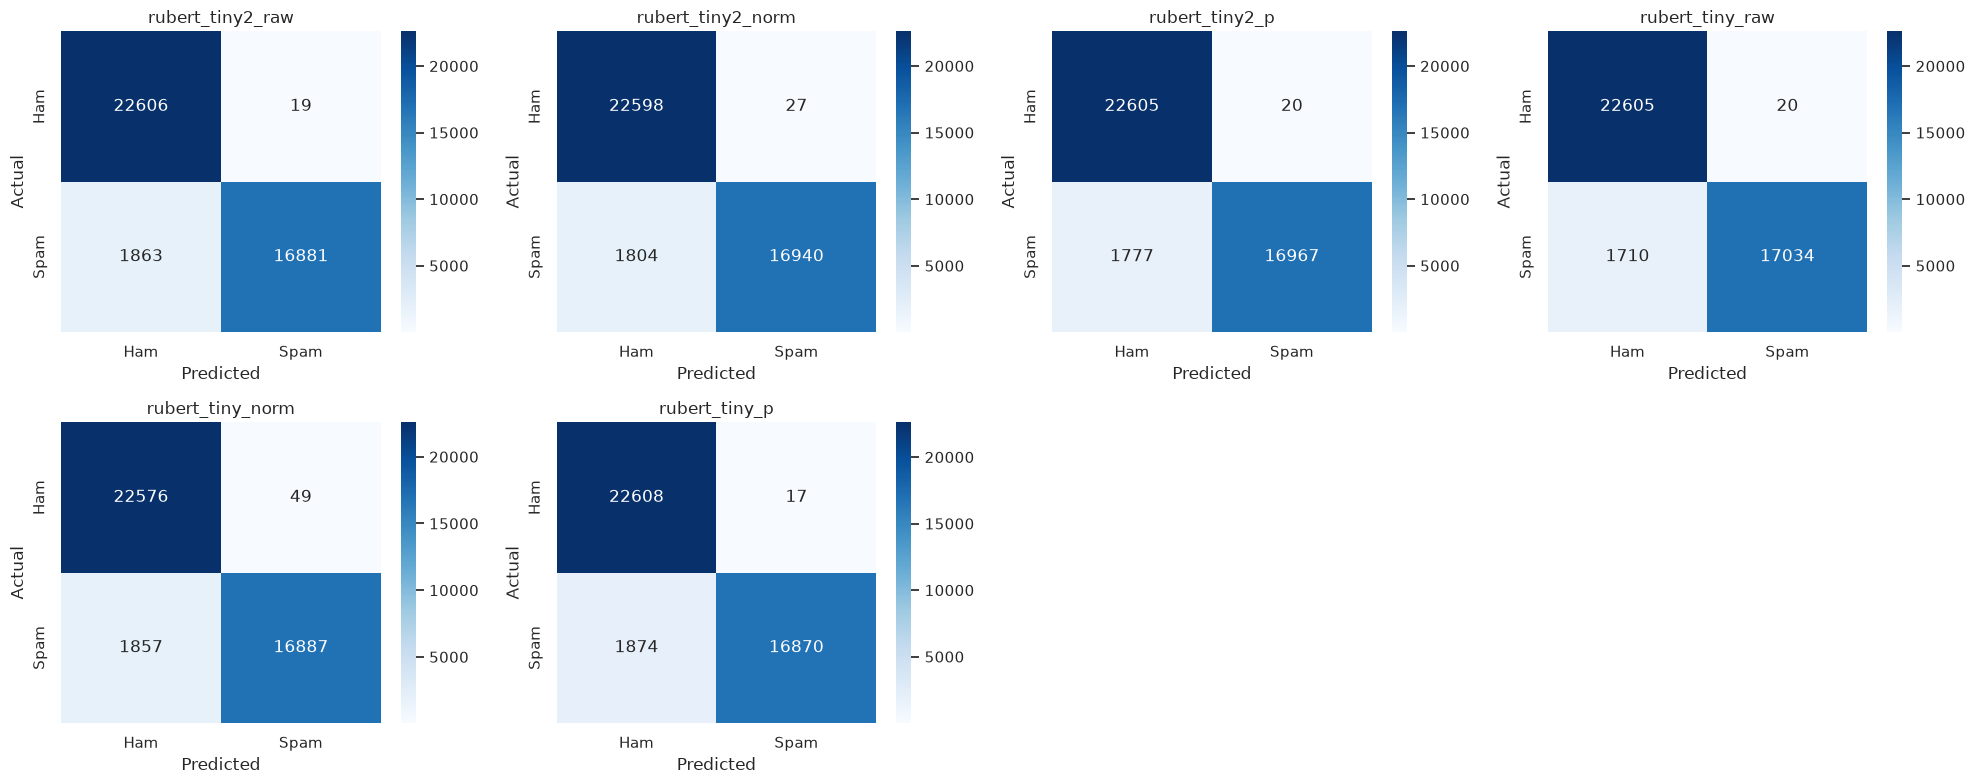

In [12]:
bert_labels = [v['label'] for v in BERT_VARIANTS]
n_bert = len(bert_labels)
n_cols = 4
n_rows = (n_bert + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for ax, model_name in zip(axes_flat, bert_labels):
    y_pred = bert_preds_all[model_name]
    cm = confusion_matrix(test_labels, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

for ax in axes_flat[len(bert_labels):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Оптимизация порога BERT

Подбор порога классификации для максимизации Precision при Recall >= 0.90
через PR-кривую для каждой BERT-модели.
Сравнение метрик до и после оптимизации.

In [13]:
thr_results_all = {}

for variant in BERT_VARIANTS:
    label = variant['label']
    thr_results_all[label] = optimize_threshold(
        test_labels, bert_proba_all[label], target_recall=0.90,
    )

thr_df = pd.DataFrame([
    {
        'model': label,
        'threshold': thr_results_all[label]['threshold'],
        'precision': thr_results_all[label]['precision'],
        'recall': thr_results_all[label]['recall'],
    }
    for label in thr_results_all
]).sort_values('precision', ascending=False).reset_index(drop=True)

thr_df

,model,threshold,precision,recall
0,rubert_tiny_p,0.939308,0.998993,0.900075
1,rubert_tiny2_raw,0.856187,0.998876,0.900662
2,rubert_tiny_raw,0.814425,0.998827,0.908771
3,rubert_tiny2_p,0.951362,0.998823,0.905250
4,rubert_tiny2_norm,0.815507,0.998409,0.903809
5,rubert_tiny_norm,0.802793,0.997107,0.900928


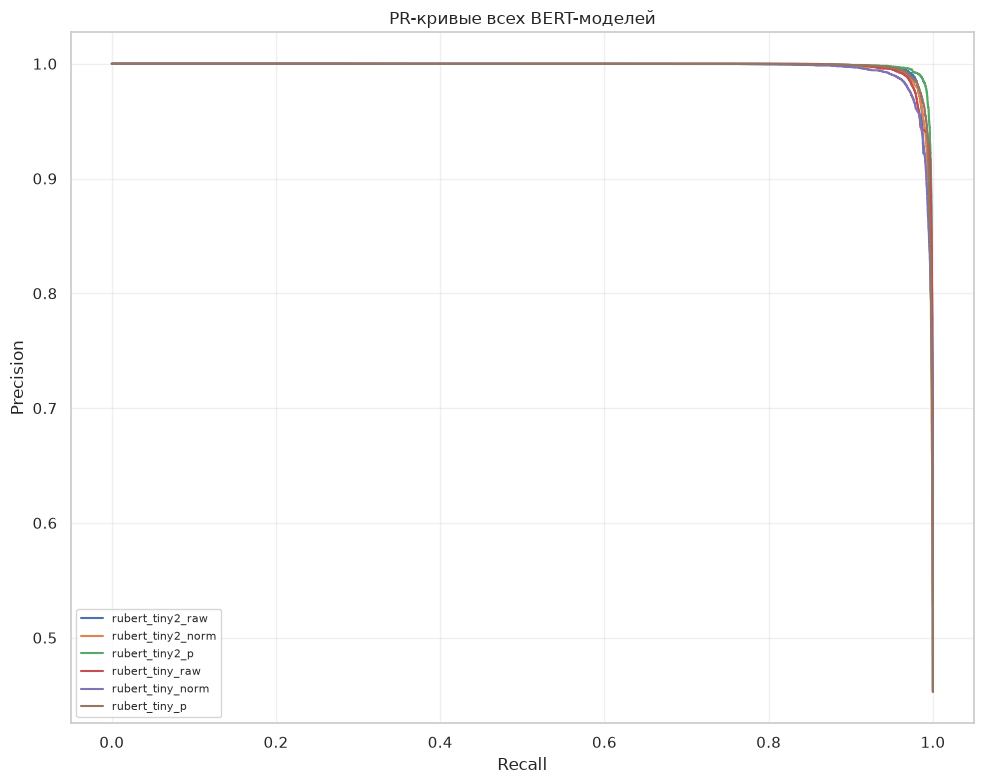

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

for variant in BERT_VARIANTS:
    label = variant['label']
    precision, recall, _ = precision_recall_curve(test_labels, bert_proba_all[label])
    ax.plot(recall, precision, label=label, linewidth=1.5)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR-кривые всех BERT-моделей')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Анализ ошибок BERT

Анализируются false positives (ham, ошибочно классифицированный как spam)
и false negatives (spam, пропущенный моделью).
Для каждой BERT-модели и каждой категории выводятся топ-10 наиболее уверенных ошибок.

In [15]:
for variant in BERT_VARIANTS:
    label = variant['label']
    preds = bert_preds_all[label]
    proba = bert_proba_all[label]

    fp_mask = (test_labels == 0) & (preds == 1)
    fp_indices = np.where(fp_mask)[0]
    fp_confidence = proba[fp_indices]
    fp_sorted = fp_indices[np.argsort(-fp_confidence)]

    print(f'\n{label} — False Positives: {fp_mask.sum()}')
    print(f'Топ-10 FP (ham -> spam, наиболее уверенные):\n')
    for idx in fp_sorted[:10]:
        text = raw_texts[idx][:150]
        print(f'  [prob={proba[idx]:.4f}] {text}\n')
    print()


rubert_tiny2_raw — False Positives: 19
Топ-10 FP (ham -> spam, наиболее уверенные):

  [prob=0.9761] Есть, пиши в лс

  [prob=0.9653] Работа в Москве! В столовую на раздачу и кассу требуются сотрудники. С 10.00 до 19.00. 2500 смена, питание бесплатно. м. Озёрная.

  [prob=0.9581] https://t.me/fsgn_active

  [prob=0.9561] https://t.me/jobrudn/2600

  [prob=0.9546] Нищебродским деньгам радоваться 🤦‍♀️

  [prob=0.9477] единороги делают меня счастливым каждый день. ЕДИНОРОГИ, ВПЕРЕД!!!!

  [prob=0.9431] Беседа мехмата в ТГ: https://t.me/+wrA-Fcx_PYA0YTYy

  [prob=0.9411] мечта+труд=успех👀

  [prob=0.9315] ТВОЮ МАТЬ, У МЕНЯ ДАЖЕ ПИСЬМО НЕ ОТПРАВЛЯЕТСЯ ИЗ-ЗА СБОЕВ 
ПИШЕТ, ЧТО В ОЧЕРЕДИ

  [prob=0.9151] https://band.link/Zqyka



rubert_tiny2_norm — False Positives: 27
Топ-10 FP (ham -> spam, наиболее уверенные):

  [prob=0.9760] Работа в Москве! В столовую на раздачу и кассу требуются сотрудники. С 10.00 до 19.00. 2500 смена, питание бесплатно. м. Озёрная.

  [prob=0.9491] Есть, пиши в лс



In [16]:
for variant in BERT_VARIANTS:
    label = variant['label']
    preds = bert_preds_all[label]
    proba = bert_proba_all[label]

    fn_mask = (test_labels == 1) & (preds == 0)
    fn_indices = np.where(fn_mask)[0]
    fn_confidence = 1 - proba[fn_indices]
    fn_sorted = fn_indices[np.argsort(-fn_confidence)]

    print(f'\n{label} — False Negatives: {fn_mask.sum()}')
    print(f'Топ-10 FN (spam -> ham, наиболее уверенные):\n')
    for idx in fn_sorted[:10]:
        text = raw_texts[idx][:150]
        print(f'  [prob={proba[idx]:.4f}] {text}\n')
    print()


rubert_tiny2_raw — False Negatives: 1863
Топ-10 FN (spam -> ham, наиболее уверенные):

  [prob=0.0057] Почему так долго? Вы про «οριστική άδεια διαμονής», пятилетний? Мне дали за 6 месяцев. Вас на собеседование приглашали?

  [prob=0.0059] Κυριακή - воскресенье

  [prob=0.0059] Σάββατο суббота

  [prob=0.0065] Но государство их поддерживает если им дали возможность попасть в раду

  [prob=0.0065] Добрый день! Подскажите пожалуйста, есть ли возможность попасть в государственный (!)детский сад с российским гражданством в Ереване? Если да, что для

  [prob=0.0074] 11.75 البته

  [prob=0.0076] Computer البته

  [prob=0.0076] π899

  [prob=0.0078] 92 دورنگ

  [prob=0.0079] Чтоб увеличить длину, надо с утра принимать обычный, советский…читать продолжение в источнике



rubert_tiny2_norm — False Negatives: 1804
Топ-10 FN (spam -> ham, наиболее уверенные):

  [prob=0.0190] 𝙷𝚒

  [prob=0.0190] 𝐇𝐢

  [prob=0.0190] 𝗛𝗶

  [prob=0.0190] 𝑯𝒊

  [prob=0.0190] 𝐻𝒾

  [prob=0.0190] 𝓗𝓲

  [prob=0.0193] 𝑯

## Распределение ошибок по длине текста

Анализируется зависимость количества и типа ошибок от длины сообщения
для каждой BERT-модели.
Тексты разбиваются на 5 бинов: 0-50, 50-100, 100-200, 200-500, 500+ символов.

In [17]:
text_lengths = np.array([len(t) for t in raw_texts])
bins = [0, 50, 100, 200, 500, 100000]
bin_labels = ['0-50', '50-100', '100-200', '200-500', '500+']
bin_idx = np.digitize(text_lengths, bins) - 1
bin_idx = np.clip(bin_idx, 0, len(bin_labels) - 1)

error_tables = {}

for variant in BERT_VARIANTS:
    label = variant['label']
    preds = bert_preds_all[label]
    error_data = []
    for i, bl in enumerate(bin_labels):
        mask = bin_idx == i
        total = int(mask.sum())
        if total > 0:
            errors = int((preds[mask] != test_labels[mask]).sum())
            fp_count = int(((test_labels[mask] == 0) & (preds[mask] == 1)).sum())
            fn_count = int(((test_labels[mask] == 1) & (preds[mask] == 0)).sum())
        else:
            errors = fp_count = fn_count = 0
        error_data.append({
            'length': bl,
            'total': total,
            'errors': errors,
            'error_rate': errors / total if total > 0 else 0.0,
            'fp': fp_count,
            'fn': fn_count,
        })
    error_tables[label] = pd.DataFrame(error_data)

for label, edf in error_tables.items():
    print(f'\n{label}')
    print(edf.to_string(index=False))


rubert_tiny2_raw
 length  total  errors  error_rate  fp   fn
   0-50  10928    1429    0.130765  11 1418
 50-100   9204     209    0.022708   5  204
100-200   9929     142    0.014302   2  140
200-500   8572      89    0.010383   0   89
   500+   2736      13    0.004751   1   12

rubert_tiny2_norm
 length  total  errors  error_rate  fp   fn
   0-50  10928    1440    0.131772  11 1429
 50-100   9204     134    0.014559   9  125
100-200   9929      98    0.009870   5   93
200-500   8572      87    0.010149   1   86
   500+   2736      72    0.026316   1   71

rubert_tiny2_p
 length  total  errors  error_rate  fp   fn
   0-50  10928    1095    0.100201   8 1087
 50-100   9204     202    0.021947   3  199
100-200   9929     191    0.019237   6  185
200-500   8572     188    0.021932   2  186
   500+   2736     121    0.044225   1  120

rubert_tiny_raw
 length  total  errors  error_rate  fp   fn
   0-50  10928    1247    0.114111   9 1238
 50-100   9204     210    0.022816   9  201
100-20

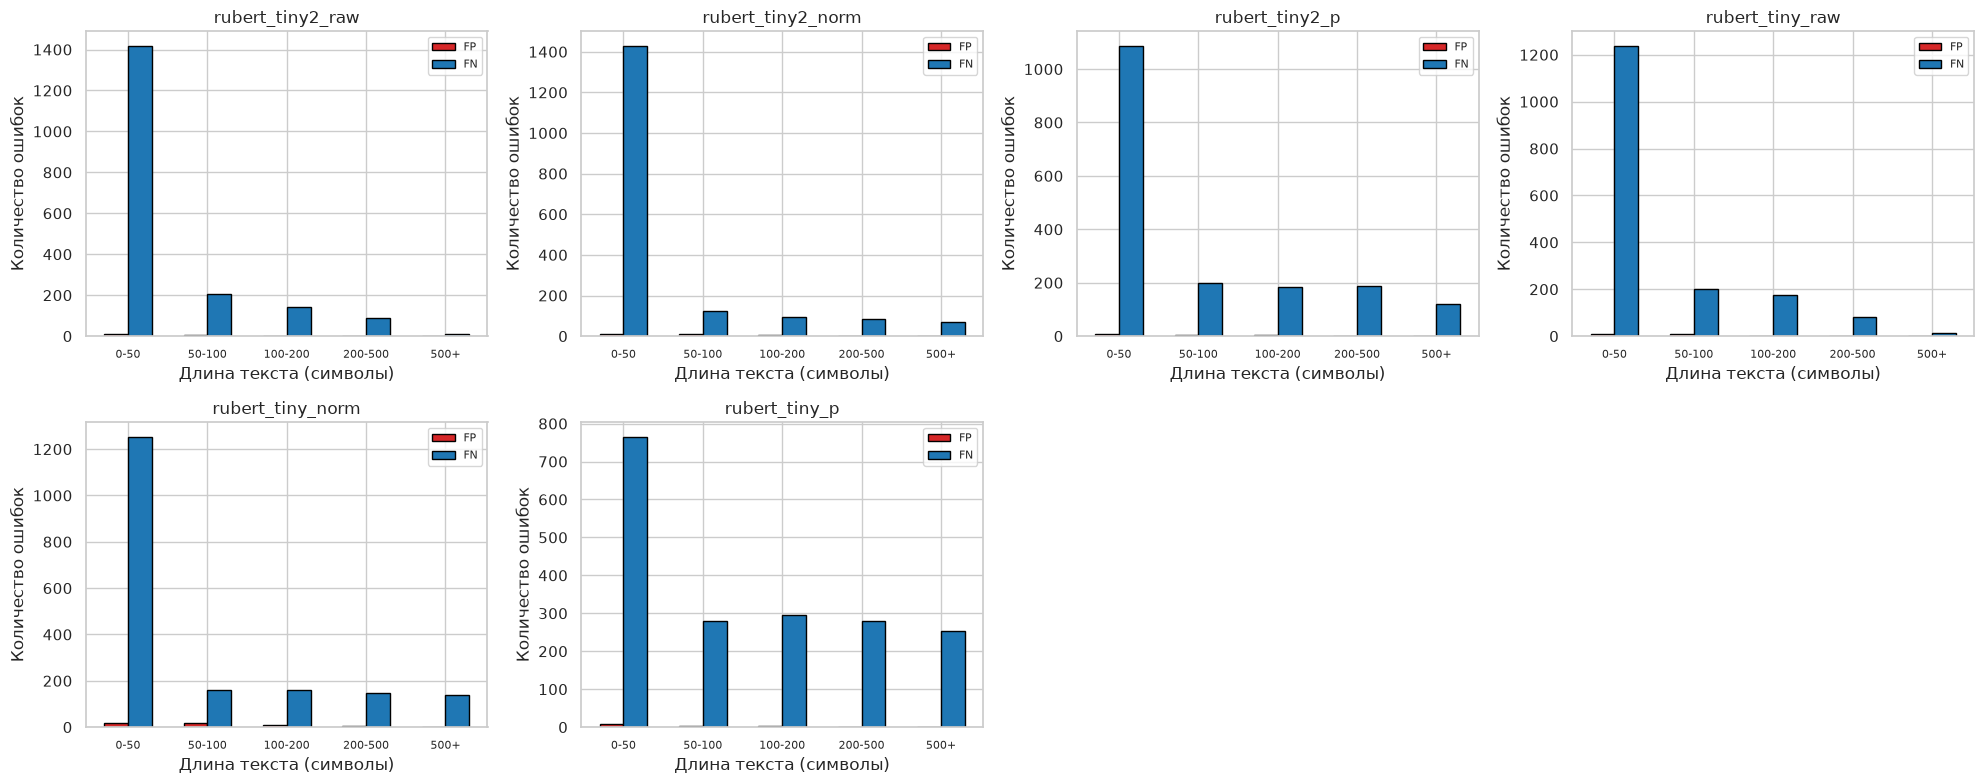

In [18]:
n_bert = len(BERT_VARIANTS)
n_cols = 4
n_rows = (n_bert + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

x = np.arange(len(bin_labels))

for ax, variant in zip(axes_flat, BERT_VARIANTS):
    label = variant['label']
    edf = error_tables[label]
    ax.bar(x - 0.15, edf['fp'], 0.3, label='FP', color='tab:red', edgecolor='black')
    ax.bar(x + 0.15, edf['fn'], 0.3, label='FN', color='tab:blue', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, fontsize=8)
    ax.set_xlabel('Длина текста (символы)')
    ax.set_ylabel('Количество ошибок')
    ax.set_title(label)
    ax.legend(fontsize=8)

for ax in axes_flat[len(BERT_VARIANTS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Замер latency

Замеряется скорость инференса на CPU для оценки пригодности к production-развёртыванию.
Для всех BERT-моделей используется `benchmark_cpu_inference` на 1000 сообщений
из соответствующей колонки текста.
Для классических моделей — `predict_message` с полным циклом предобработки.

In [19]:
bert_latency_all = {}

for variant in BERT_VARIANTS:
    label = variant['label']
    model_path = str(MODELS_DIR / variant['dir'])
    model_bench = AutoModelForSequenceClassification.from_pretrained(model_path)
    tokenizer_bench = AutoTokenizer.from_pretrained(model_path)
    texts = df_test[variant['text_col']].astype(str).tolist()[:1000]
    bert_latency_all[label] = benchmark_cpu_inference(
        model_bench,
        tokenizer_bench,
        texts,
        batch_size=32,
        max_length=variant['max_length'],
    )
    print(f'{label}: {bert_latency_all[label]}')

bert_latency = bert_latency_all['rubert_tiny2_norm']
print(f'\nBERT latency (rubert_tiny2_norm): {bert_latency}')

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

rubert_tiny2_raw: {'avg_ms_per_msg': 1.1, 'p95_ms_per_msg': 2.3, 'throughput_msgs_per_sec': 907.17}


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

rubert_tiny2_norm: {'avg_ms_per_msg': 1.08, 'p95_ms_per_msg': 2.26, 'throughput_msgs_per_sec': 924.45}


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

...

rubert_tiny_raw: {'avg_ms_per_msg': 1.68, 'p95_ms_per_msg': 3.46, 'throughput_msgs_per_sec': 595.08}


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

rubert_tiny_norm: {'avg_ms_per_msg': 1.62, 'p95_ms_per_msg': 3.39, 'throughput_msgs_per_sec': 616.03}


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

rubert_tiny_p: {'avg_ms_per_msg': 1.49, 'p95_ms_per_msg': 3.05, 'throughput_msgs_per_sec': 671.99}

BERT latency (rubert_tiny2_norm): {'avg_ms_per_msg': 1.08, 'p95_ms_per_msg': 2.26, 'throughput_msgs_per_sec': 924.45}


In [20]:
sample_size = 1000
sample_raw = raw_texts[:sample_size]

classic_latency = {}
for name, model in classic_models.items():
    start = time.perf_counter()
    for text in sample_raw:
        predict_message(text, vectorizer, scaler, model, char_vectorizer)
    elapsed = time.perf_counter() - start
    classic_latency[name] = {
        'avg_ms_per_msg': round(elapsed / sample_size * 1000, 2),
        'throughput_msgs_per_sec': round(sample_size / elapsed, 2),
    }
    print(f'{name}: {classic_latency[name]}')

lr: {'avg_ms_per_msg': 1.77, 'throughput_msgs_per_sec': 565.03}
lgbm: {'avg_ms_per_msg': 19.36, 'throughput_msgs_per_sec': 51.65}
catboost: {'avg_ms_per_msg': 5.31, 'throughput_msgs_per_sec': 188.25}


In [21]:
latency_data = []

for variant in BERT_VARIANTS:
    label = variant['label']
    latency_data.append({
        'model': label,
        'avg_ms_per_msg': bert_latency_all[label]['avg_ms_per_msg'],
        'p95_ms_per_msg': bert_latency_all[label]['p95_ms_per_msg'],
        'throughput_msgs_per_sec': bert_latency_all[label]['throughput_msgs_per_sec'],
    })

for name, lat in classic_latency.items():
    latency_data.append({
        'model': f'classic_{name}',
        'avg_ms_per_msg': lat['avg_ms_per_msg'],
        'p95_ms_per_msg': None,
        'throughput_msgs_per_sec': lat['throughput_msgs_per_sec'],
    })

latency_df = pd.DataFrame(latency_data).sort_values('avg_ms_per_msg')
latency_df

,model,avg_ms_per_msg,p95_ms_per_msg,throughput_msgs_per_sec
2,rubert_tiny2_p,0.89,1.83,1118.22
1,rubert_tiny2_norm,1.08,2.26,924.45
0,rubert_tiny2_raw,1.10,2.30,907.17
5,rubert_tiny_p,1.49,3.05,671.99
4,rubert_tiny_norm,1.62,3.39,616.03
3,rubert_tiny_raw,1.68,3.46,595.08
6,classic_lr,1.77,NaN,565.03
8,classic_catboost,5.31,NaN,188.25
7,classic_lgbm,19.36,NaN,51.65


## Сохранение результатов

Сводная таблица метрик сохраняется в `data/interim/external_evaluation_results.csv`
для использования в последующих ноутбуках.

In [22]:
results_df.to_csv(INTERIM_DIR / 'external_evaluation_results.csv', index=False)
print(f'Результаты сохранены: {INTERIM_DIR / "external_evaluation_results.csv"}')
print(f'Строк: {len(results_df)}')

Результаты сохранены: /home/sophrosyne/STANKIN_AntiSpam_Bot/data/interim/external_evaluation_results.csv
Строк: 9
